`conda activate cellcharter`

In [ ]:
import anndata as ad
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io
import os
import cell2location

In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('sp.h5ad')

In [ ]:
# Exclude sample that contains a significant portion of healthy tissue (cerebellar region)
adata = adata[ ~adata.obs['sample'].isin(['DMG1'])].copy()
adata

AnnData object with n_obs × n_vars = 11848 × 15284
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '_indices', '_scvi_batch', '_scvi_labels', 'AC_like', 'Astrocyte', 'B_cell', 'COP_like', 'Cilia_like', 'Endothelial', 'GB_like', 'GW_like', 'Mono_neutrophil', 'Mural', 'Neuron', 'OPC', 'OPC_like', 'Oligodendrocyte', 'RG_like', 'TAM_C1Q', 'TAM_IL1B', 'TAM_homeostatic', 'TAM_lipid_laden', 'TAM_scavenger', 'TD_like', 'T_cell', 'Tri_IPC_like', 'nIPC_like', 'total RNA counts', 'Total cell abundance (sum_f w_sf)', 'RNA detection sensitivity (y_s)', 'mean_nUMI_factorsfact_0', 'mean_nUMI_factorsfact_1', 'mean_nUMI_factorsfact_2', 'mean_nUMI_factorsfact_3', 'mean_nUMI_factorsfact_4', 'mean_nUMI_factorsfact_5', 'mean_nUMI_factorsfact_6', 'mean_nUMI_factorsfact_7', 'mean_nUMI_factorsf

In [ ]:
nmf_df = pd.DataFrame(adata.uns['mod_coloc_n_fact7']['post_sample_means']['location_factors'])
nmf_df.index = adata.uns['mod_coloc_n_fact7']['obs_names']
nmf_df.columns = adata.uns['mod_coloc_n_fact7']['fact_names']
nmf_df.head()

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.0,0.000000,0.0,0.083814,0.226187,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.0,0.038803,0.0,0.103664,0.114554,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.0,0.000000,0.0,0.120920,0.097331,0.0,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.0,0.023437,0.0,0.110779,0.048015,0.0,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.0,0.000000,0.0,0.098536,0.408341,0.0,0.000000


In [ ]:
# Ensure that 'nmf_df' index and 'adata.obs_names' are aligned in type 
nmf_df = nmf_df.loc[adata.obs_names]
nmf_df

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6
spot_id,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.000000,0.000000,0.000000,0.083814,0.226187,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.000000,0.038803,0.000000,0.103664,0.114554,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.000000,0.000000,0.000000,0.120920,0.097331,0.0,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.000000,0.023437,0.000000,0.110779,0.048015,0.0,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.000000,0.000000,0.000000,0.098536,0.408341,0.0,0.000000
...,...,...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,0.019947,0.923844,0.318662,0.067453,0.133061,0.0,0.000000
DMG5_TTGTTCAGTGTGCTAC-1,0.036767,0.000000,0.000000,0.000000,1.568617,0.0,0.000000
DMG5_TTGTTGTGTGTCAAGA-1,0.070362,0.163486,0.030180,0.002634,0.596495,0.0,0.000000


In [ ]:
nmf_df = nmf_df.loc[:,['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]
nmf_df

,fact_0,fact_2,fact_4,fact_1,fact_6
spot_id,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.000000,0.000000,0.226187,0.000000,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.000000,0.000000,0.114554,0.038803,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.000000,0.000000,0.097331,0.000000,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.000000,0.000000,0.048015,0.023437,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.000000,0.000000,0.408341,0.000000,0.000000
...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,0.019947,0.318662,0.133061,0.923844,0.000000
DMG5_TTGTTCAGTGTGCTAC-1,0.036767,0.000000,1.568617,0.000000,0.000000
DMG5_TTGTTGTGTGTCAAGA-1,0.070362,0.030180,0.596495,0.163486,0.000000


In [ ]:
# Define the samples classified as 'diagnosis' and 'relapse'
relapse_samples = ['BT01_192_core_HE', 'VUMC_17_pons_HE', 'VUMC_11_pons_HE']

adata.obs['treatment'] = adata.obs['sample'].apply(lambda x: 'relapse' if x in relapse_samples else 'diagnosis')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


niche_data = nmf_df[['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]
treatment_data = adata.obs['treatment']


niche_data['DotID'] = niche_data.index  
combined_df = niche_data.melt(id_vars='DotID', var_name='Niche', value_name='Proportion')
combined_df['Treatment'] = combined_df['DotID'].map(treatment_data)
combined_df

,DotID,Niche,Proportion,Treatment
0,BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,fact_0,0.0,relapse
1,BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,fact_0,0.0,relapse
2,BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,fact_0,0.0,relapse
3,BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,fact_0,0.0,relapse
4,BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,fact_0,0.0,relapse
...,...,...,...,...
59235,DMG5_TTGTGTTTCCCGAAAG-1,fact_6,0.0,diagnosis
59236,DMG5_TTGTTCAGTGTGCTAC-1,fact_6,0.0,diagnosis
59237,DMG5_TTGTTGTGTGTCAAGA-1,fact_6,0.0,diagnosis
59238,DMG5_TTGTTTCACATCCAGG-1,fact_6,0.0,diagnosis


Niche      p-value    Interpretation
------------------------------
fact_0     0.000e+00  Significant
fact_2     8.743e-07  Significant
fact_4     6.496e-99  Significant
fact_1     7.053e-91  Significant
fact_6     5.873e-150 Significant


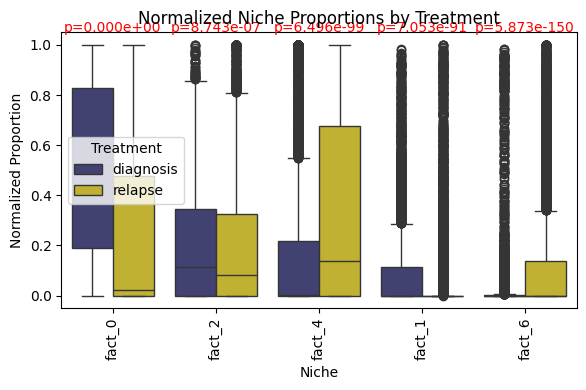

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

niche_data = nmf_df[['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]
treatment_data = adata.obs['treatment']

niche_data['DotID'] = niche_data.index 
combined_df = niche_data.melt(id_vars='DotID', var_name='Niche', value_name='Proportion')
combined_df['Treatment'] = combined_df['DotID'].map(treatment_data)

combined_df['Normalized_Proportion'] = combined_df.groupby('DotID')['Proportion'].transform(lambda x: x / x.sum())

combined_df['Treatment'] = pd.Categorical(combined_df['Treatment'], categories=['diagnosis', 'relapse'], ordered=True)

combined_df = combined_df.dropna(subset=['Normalized_Proportion'])

plt.figure(figsize=(6, 4))
boxplot = sns.boxplot(
    data=combined_df,
    x='Niche',
    y='Normalized_Proportion',
    hue='Treatment',
    palette={'diagnosis': '#393b79', 'relapse': '#d7c31b'}
)
plt.title('Normalized Niche Proportions by Treatment')
plt.ylabel('Normalized Proportion')
plt.xlabel('Niche')
plt.legend(title='Treatment')
plt.xticks(rotation=90)

# Perform statistical comparisons
niches = combined_df['Niche'].unique()
y_max = combined_df['Normalized_Proportion'].max()

print(f"{'Niche':<10} {'p-value':<10} {'Interpretation'}")
print("-" * 30)

for niche in niches:
    diagnosis = combined_df[(combined_df['Niche'] == niche) & (combined_df['Treatment'] == 'diagnosis')]['Normalized_Proportion']
    relapse = combined_df[(combined_df['Niche'] == niche) & (combined_df['Treatment'] == 'relapse')]['Normalized_Proportion']
    
    if len(diagnosis) < 2 or len(relapse) < 2 or diagnosis.nunique() == 1 or relapse.nunique() == 1:
        print(f"{niche:<10} {'N/A':<10} Insufficient data")
        continue
    
    stat, p_value = mannwhitneyu(diagnosis, relapse, alternative='two-sided')
    
    interpretation = "Significant" if p_value < 0.05 else "Not Significant"
    print(f"{niche:<10} {p_value:<10.3e} {interpretation}")
    
    x_position = niches.tolist().index(niche)
    y_position = y_max + 0.05
    plt.text(x_position, y_position, f'p={p_value:.3e}', ha='center', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('figures/niche_proportions_clinical_status.pdf')
plt.show()